In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D


>>> Running Experiment for Amplitude A = 50 (DX = 25)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Validation Accuracy for A=50: 0.3465

>>> Running Experiment for Amplitude A = 100 (DX = 25)
Final Validation Accuracy for A=100: 0.3980

>>> Running Experiment for Amplitude A = 150 (DX = 25)
Final Validation Accuracy for A=150: 0.5000

>>> Running Experiment for Amplitude A = 200 (DX = 25)
Final Validation Accuracy for A=200: 0.6320

>>> Running Experiment for Amplitude A = 250 (DX = 25)
Final Validation Accuracy for A=250: 0.7345

>>> Running Experiment for Amplitude A = 300 (DX = 25)
Final Validation Accuracy for A=300: 0.7755

>>> Running Experiment for Amplitude A = 350 (DX = 25)
Final Validation Accuracy for A=350: 0.8540

>>> Running Experiment for Amplitude A = 400 (DX = 25)
Final Validation Accuracy for A=400: 0.8535

>>> Running Experiment for Amplitude A = 450 (DX = 25)
Final Validation Accuracy for A=450: 0.8695

>>> Running Experiment for Amplitude A = 500 (DX = 25)
Final Validation Accuracy for A=500: 0.9320

>>> Running Experiment for Amplitude A = 550 (DX = 25)
F

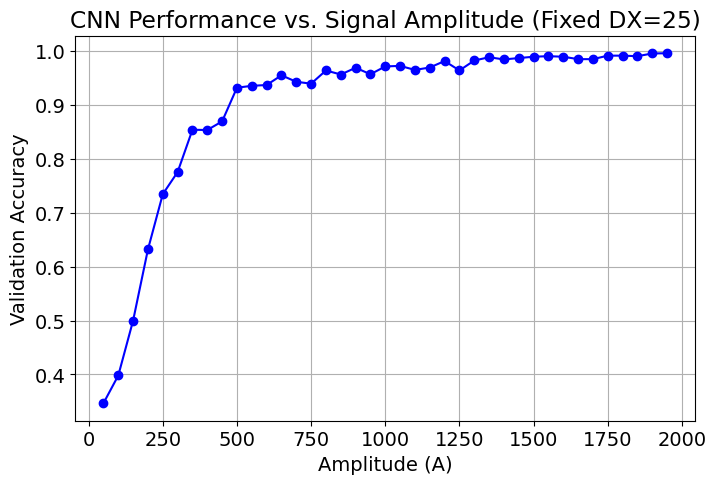

In [3]:
DX = 25
Z = 12
N = 10000
L = 60
bias = 5
amplitudes=[]
for i in range(50,2000,50):
  amplitudes.append(i)

jump = lambda drift, stdev: int(np.random.normal(drift,stdev))
def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))
results = []

best_val_acc = 0
best_fit = None
best_model = None
best_A = 0
all_accuracies = []

for A in amplitudes:
    print(f"\n>>> Running Experiment for Amplitude A = {A} (DX = {DX})")

    y = [0] * N
    x = [[0] * L for i in range(N)]
    for i in range(N):
        if i > 0: x[i][0] = x[i-1][-1] + jump(bias, DX)
        for j in range(1, L):
            x[i][j] = x[i][j-1] + jump(bias, DX)

        y[i] = i % 3
        if y[i] > 0:
            j0 = np.random.randint(0, L-1-Z)
            sign = 3 - 2 * y[i]
            for j in range(Z):
                x[i][j0+j] += sign * pattern(j, Z, A)

    X_data = np.array(x)
    Y_data = tf.keras.utils.to_categorical(y, 3)


    xm = X_data.mean(axis=1)
    for i in range(N): X_data[i] = X_data[i] - xm[i]
    std = X_data.std(axis=1)
    for i in range(N): X_data[i] = X_data[i] / std[i]
    X_data = X_data.reshape(N, L, 1)

    perc_train = 0.8
    N_train = int(N * perc_train)
    x_train, x_val = X_data[:N_train], X_data[N_train:]
    y_train, y_val = Y_data[:N_train], Y_data[N_train:]
    reg = tf.keras.regularizers.l2(0.2)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05,
                                        seed=None)

    model = Sequential()
    model.add(Conv1D(filters=5, kernel_size=11,
                     kernel_initializer=ini,
                     kernel_regularizer=reg,
                     activation='relu',
                     input_shape=(L,1)))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7,
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Train
    fit = model.fit(x_train, y_train, epochs=10, batch_size=32,
                    validation_data=(x_val, y_val), verbose=0)

    final_acc = fit.history['val_accuracy'][-1]
    results.append(final_acc)
    print(f"Final Validation Accuracy for A={A}: {final_acc:.4f}")

    current_acc = fit.history['val_accuracy'][-1]
    all_accuracies.append(current_acc)

    # Track the best model
    if current_acc > best_val_acc:
        best_val_acc = current_acc
        best_fit = fit
        best_model = model
        best_A = A

print(f"\nBest Performance found at A = {best_A} with Accuracy = {best_val_acc:.4f}")
plt.figure(figsize=(8,5))
plt.plot(amplitudes, results, marker='o', linestyle='-', color='b')
plt.title("CNN Performance vs. Signal Amplitude (Fixed DX=25)")
plt.xlabel("Amplitude (A)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()

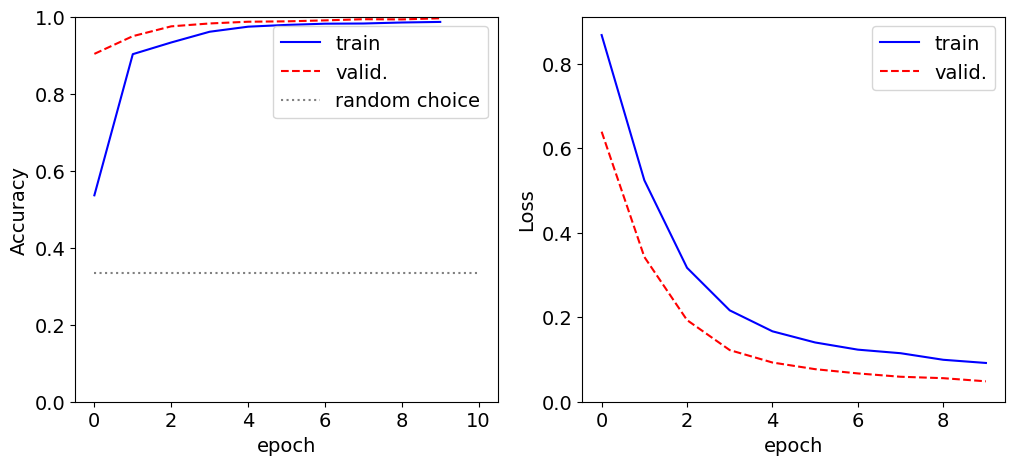

(11, 1, 5)
(5, 1, 11)


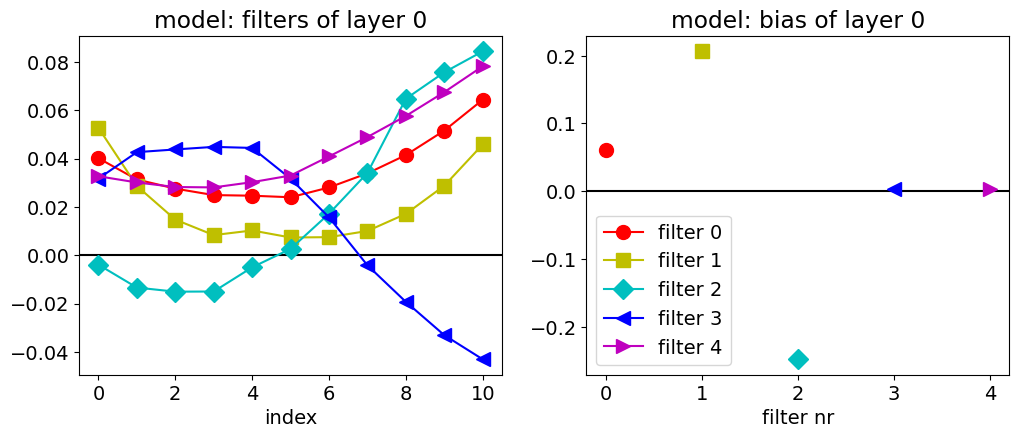

(7, 5, 5)
(5, 5, 7)


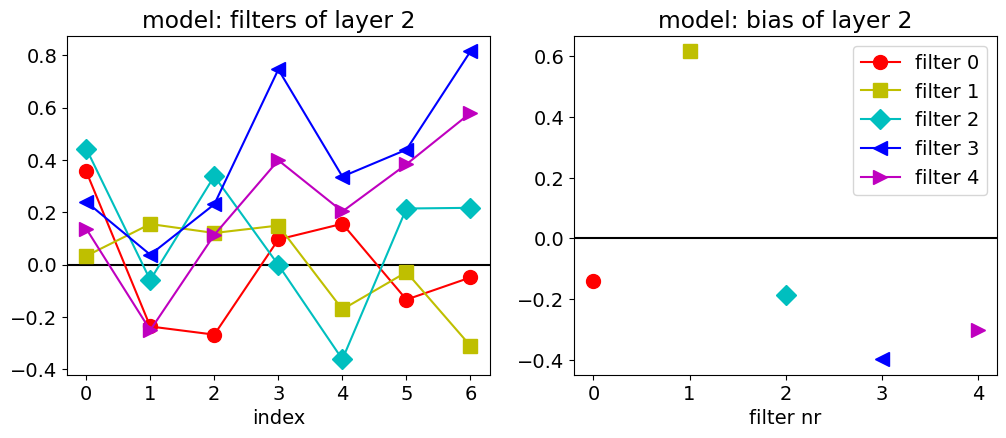

In [5]:

def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10

    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias

    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()

def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    epochs=len(fit.history['accuracy'])
    ax=AX[0]
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,epochs),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
Show_history(best_fit)
Show_weights(best_model,0)
Show_weights(model,2)